In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
from glob import glob
import glob

In [3]:
imu_sensor_locations = ['Pelvis', 'L5', 'L3', 'T12', 'T8', 'Neck', 'Head', 'RightShoulder', 'RightUpperArm', 'RightForeArm', 'RightHand', 'LeftShoulder', 'LeftUpperArm', 'LeftForeArm', 'LeftHand', 'RightUpperLeg', 'RightLowerLeg',
                    'RightFoot', 'RightToe', 'LeftUpperLeg', 'LeftLowerLeg', 'LeftFoot', 'LeftToe']

insole_sensor_locations = ['Arch', 'Hallux', 'Heel_L', 'Heel_R', 'Met1', 'Met3', 'Met5', 'Toes']

participant_num = [1, 2, 3, 4, 5, 7, 8, 10, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25]

In [4]:
# import csv
insole_df = pd.read_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/base_df_insole_df.csv')

In [5]:
insole_df = insole_df.sort_values(by=['participant_id', 'task', 'time', 'sensor_location'])
# insole_df['walk_mode'].value_counts()

# show all the rows in the df
pd.set_option('display.max_rows', None)

In [6]:
insole_df['walk_mode'] = insole_df['walk_mode'].replace({'pavement_up': 'stairs_up', 'pavement_down': 'stairs_down'})

## prexisting labels insole segmentation

In [7]:
preex_insole = insole_df.copy()

In [8]:
# Function to pair heel strikes with the next toe-off event
def pair_heel_strikes_toe_offs(heel_strikes, toe_offs):
    pairs = []
    toe_idx = 0
    # Loop over each heel strike
    for heel in heel_strikes:
        # Find the next toe-off that occurs after the heel strike
        while toe_idx < len(toe_offs) and toe_offs[toe_idx] < heel:
            toe_idx += 1
        if toe_idx < len(toe_offs):
            # Pair found
            pairs.append((heel, toe_offs[toe_idx]))
            toe_idx += 1  # Move to the next toe-off for the next pair
    return pairs


In [9]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# Define a function to process each group more efficiently
def process_participant_task(participant_id, task_id, group):
    # Define heel strikes and toe-offs for the right and left foot
    right_foot_step = group[(group['insoles_RightFoot_is_step'])]['time'].values
    right_foot_off = group[(group['insoles_RightFoot_is_lifted'])]['time'].values
    left_foot_step = group[(group['insoles_LeftFoot_is_step'])]['time'].values
    left_foot_off = group[(group['insoles_LeftFoot_is_lifted'])]['time'].values

    # Pair strikes and toe-offs
    right_foot_steps = pair_heel_strikes_toe_offs(right_foot_step, right_foot_off)
    left_foot_steps = pair_heel_strikes_toe_offs(left_foot_step, left_foot_off)

    # Create a mask for right and left steps
    right_step_mask = np.zeros(group.shape[0], dtype=int)
    left_step_mask = np.zeros(group.shape[0], dtype=int)

    # Update the step counts using vectorized operations
    for i, (start, end) in enumerate(right_foot_steps):
        mask = (group['time'] >= start) & (group['time'] <= end)
        right_step_mask[mask] = i + 1

    for i, (start, end) in enumerate(left_foot_steps):
        mask = (group['time'] >= start) & (group['time'] <= end)
        left_step_mask[mask] = i + 1

    # Assign masks to the group directly
    group['right_step_count'] = right_step_mask
    group['left_step_count'] = left_step_mask

    return group


In [10]:
# Parallelize the group processing
unique_groups = insole_df.groupby(['participant_id', 'task'])

# Run the function in parallel using joblib
results = Parallel(n_jobs=-1)(delayed(process_participant_task)(participant_id, task_id, group)
                              for (participant_id, task_id), group in unique_groups)

# Combine the processed DataFrames
preex_insole = pd.concat(results, axis=0)

In [11]:
# replace 0.0 with na values in right and left gait cycle
preex_insole['right_gait_cycle'] = preex_insole['right_step_count'].replace(0, np.nan)
preex_insole['left_gait_cycle'] = preex_insole['left_step_count'].replace(0, np.nan)

# fill until the start of the next step, which is the same as counting gait cycles
preex_insole['right_gait_cycle'] = preex_insole['right_gait_cycle'].fillna(method='ffill')
preex_insole['left_gait_cycle'] = preex_insole['left_gait_cycle'].fillna(method='ffill')

# gait cycle values needed to be divided by 8
preex_insole['left_gait_cycle'] = preex_insole['left_gait_cycle'].astype(int) / 8
preex_insole['right_gait_cycle'] = preex_insole['right_gait_cycle'].astype(int) / 8

# convert na values to 0
preex_insole['left_step_count'] = preex_insole['left_step_count'].fillna(0)
preex_insole['right_step_count'] = preex_insole['right_step_count'].fillna(0)

# steps values needed to be divided by 8
preex_insole['left_step_count'] = preex_insole['left_step_count'].astype(int) / 8
preex_insole['right_step_count'] = preex_insole['right_step_count'].astype(int) / 8

<ipython-input-11-b7e13f077b7f>:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  preex_insole['right_gait_cycle'] = preex_insole['right_gait_cycle'].fillna(method='ffill')
<ipython-input-11-b7e13f077b7f>:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  preex_insole['left_gait_cycle'] = preex_insole['left_gait_cycle'].fillna(method='ffill')


In [12]:
# subset only the neccesary
preex_insole = preex_insole[['time', 'participant_id', 'task', 'left_step_count', 'right_step_count', 'left_gait_cycle', 'right_gait_cycle']]

# # rename the columns in preex_insole
# preex_insole.rename(columns={'left_step_count': 'preex_left_step_count', 'right_step_count': 'preex_right_step_count',
#                              'left_gait_cycle': 'preex_left_gait_cycle', 'right_gait_cycle': 'preex_right_gait_cycle'}, inplace=True)

In [13]:
preex_insole.head()

,time,participant_id,task,left_step_count,right_step_count,left_gait_cycle,right_gait_cycle
0,0,1,A,1.0,1.0,1.0,1.0
1,0,1,A,1.0,1.0,1.0,1.0
2,0,1,A,1.0,1.0,1.0,1.0
3,0,1,A,1.0,1.0,1.0,1.0
4,0,1,A,1.0,1.0,1.0,1.0


In [14]:
# retain only one sensor location/ cumulative measurement per time stamp and participant
no_dup_preex = preex_insole.drop_duplicates(subset=['time', 'participant_id', 'task'])
no_dup_preex.reset_index(drop=True, inplace=True)

In [15]:
# merge the preexisting variable values/segmentations back into the main df
no_dup_preex = pd.merge(insole_df, no_dup_preex, on=['time', 'participant_id', 'task'], how='left')

In [16]:
no_dup_preex.head()

,time,participant_id,task,walk_mode,insoles_RightFoot_is_step,insoles_RightFoot_is_lifted,insoles_LeftFoot_is_step,insoles_LeftFoot_is_lifted,sensor_location,Left_norm,Left_raw,Right_norm,Right_raw,time_in_secs,Left_norm_cumulative,Right_norm_cumulative,left_step_count,right_step_count,left_gait_cycle,right_gait_cycle
0,0,1,A,walk,True,False,True,False,Arch,0.001299,4093.000000,0.160105,3839.406648,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0
1,0,1,A,walk,True,False,True,False,Hallux,0.000223,4094.362659,0.968475,2782.670582,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0
2,0,1,A,walk,True,False,True,False,Heel_L,0.457522,3611.384155,0.000275,4094.362659,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0
3,0,1,A,walk,True,False,True,False,Heel_R,0.372672,3485.834793,0.002728,4090.274681,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0
4,0,1,A,walk,True,False,True,False,Met1,0.001484,4091.318670,0.987995,3424.637341,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0


In [17]:
# recreating the boolean step count for the graphics below
no_dup_preex['left_step_bool'] = np.where(no_dup_preex['left_step_count'] == 0.0, False, True)
no_dup_preex['right_step_bool'] = np.where(no_dup_preex['right_step_count'] == 0.0, False, True)

In [18]:
# Create dictionaries to store ranges of True values for each participant-task combination
preex_right_step_ranges = {}
preex_left_step_ranges = {}

for p, participant_df in no_dup_preex.groupby('participant_id'):
    for t in participant_df['task'].unique():
        # Filter data for the current participant-task
        current_df = participant_df[participant_df['task'] == t].copy()

        # Process Right_Step
        true_indices_right = current_df.index[current_df['right_step_bool'] == True]
        right_ranges = []
        if not true_indices_right.empty:
            start = true_indices_right[0]
            for i in range(1, len(true_indices_right)):
                if true_indices_right[i] != true_indices_right[i - 1] + 1:
                    end = true_indices_right[i - 1]
                    right_ranges.append((start, end))
                    start = true_indices_right[i]
            right_ranges.append((start, true_indices_right[-1]))
        preex_right_step_ranges[(p, t)] = right_ranges

        # Process Left_Step
        true_indices_left = current_df.index[current_df['left_step_bool'] == True]
        left_ranges = []
        if not true_indices_left.empty:
            start = true_indices_left[0]
            for i in range(1, len(true_indices_left)):
                if true_indices_left[i] != true_indices_left[i - 1] + 1:
                    end = true_indices_left[i - 1]
                    left_ranges.append((start, end))
                    start = true_indices_left[i]
            left_ranges.append((start, true_indices_left[-1]))
        preex_left_step_ranges[(p, t)] = left_ranges



## threshold value insole segmentation

In [19]:
# all_insole_steps = []

# for p, participant_df in insole_df.groupby('participant_id'):
#     for t in participant_df['task'].unique():
#         # Filter the DataFrame for the current participant and task
#         current_df = participant_df[participant_df['task'] == t].copy()

#         # Calculate cumulative sensor values grouped by time
#         cumulative_sensors = current_df.groupby('time')[['Left_norm', 'Right_norm']].sum()

#         # normalize values in left_norm column
#         cumulative_sensors['Left_norm'] = cumulative_sensors['Left_norm'] / cumulative_sensors['Left_norm'].max()
#         cumulative_sensors['Right_norm'] = cumulative_sensors['Right_norm'] / cumulative_sensors['Right_norm'].max()

#         # Define conditions for swing and step detection
#         cumulative_sensors['Left_swing'] = cumulative_sensors['Left_norm'] <= 0.2
#         cumulative_sensors['Left_Step'] = cumulative_sensors['Left_norm'] > 0.2
#         cumulative_sensors['Right_swing'] = cumulative_sensors['Right_norm'] <= 0.2
#         cumulative_sensors['Right_Step'] = cumulative_sensors['Right_norm'] > 0.2

#         # Add participant and task information for traceability
#         cumulative_sensors['participant_id'] = p
#         cumulative_sensors['task'] = t

#         # Append the processed DataFrame to the list
#         all_insole_steps.append(cumulative_sensors)

#     print(f"Processed participant {p}")

# # Concatenate all processed DataFrames into a single DataFrame
# cumulative_pressure_insole_df = pd.concat(all_insole_steps).reset_index()

# # print("Final combined DataFrame:")
# # print(cumulative_pressure_insole_df.head())


In [20]:
# # rename the columns in cumulative_pressure_insole_df
# cumulative_pressure_insole_df.rename(columns={'Left_norm': 'Left_norm_cumulative', 'Right_norm': 'Right_norm_cumulative'}, inplace=True)

# # retain only one sensor location/ cumulative measurement per time stamp and participant
# no_dup_cumulative = cumulative_pressure_insole_df.drop_duplicates(subset=['time', 'participant_id', 'task', 'Left_norm_cumulative', 'Right_norm_cumulative'])
# no_dup_cumulative.reset_index(drop=True, inplace=True)


In [21]:
# # merge the cumulative values/segmentations back into the main df
# no_dup_cumulative = pd.merge(insole_df, no_dup_cumulative, on=['time', 'participant_id', 'task'], how='left')

In [22]:
# # Create dictionaries to store ranges of True values for each participant-task combination
# right_step_ranges = {}
# left_step_ranges = {}

# for p, participant_df in no_dup_cumulative.groupby('participant_id'):
#     for t in participant_df['task'].unique():
#         # Filter data for the current participant-task
#         current_df = participant_df[participant_df['task'] == t].copy()

#         # Process Right_Step
#         true_indices_right = current_df.index[current_df['Right_Step'] == True]
#         right_ranges = []
#         if not true_indices_right.empty:
#             start = true_indices_right[0]
#             for i in range(1, len(true_indices_right)):
#                 if true_indices_right[i] != true_indices_right[i - 1] + 1:
#                     end = true_indices_right[i - 1]
#                     right_ranges.append((start, end))
#                     start = true_indices_right[i]
#             right_ranges.append((start, true_indices_right[-1]))
#         right_step_ranges[(p, t)] = right_ranges

#         # Process Left_Step
#         true_indices_left = current_df.index[current_df['Left_Step'] == True]
#         left_ranges = []
#         if not true_indices_left.empty:
#             start = true_indices_left[0]
#             for i in range(1, len(true_indices_left)):
#                 if true_indices_left[i] != true_indices_left[i - 1] + 1:
#                     end = true_indices_left[i - 1]
#                     left_ranges.append((start, end))
#                     start = true_indices_left[i]
#             left_ranges.append((start, true_indices_left[-1]))
#         left_step_ranges[(p, t)] = left_ranges


In [23]:
# import matplotlib.pyplot as plt

# # Define the key to plot
# key = (8, "A")

# # Get the ranges for the key
# preex_right_ranges = preex_right_step_ranges.get(key, [])[:200]
# preex_left_ranges = preex_left_step_ranges.get(key, [])[:200]

# right_ranges = right_step_ranges.get(key, [])[:200]
# left_ranges = left_step_ranges.get(key, [])[:200]

# # Set up the figure
# plt.figure(figsize=(60, 5))

# # Plot Preex Right Step Ranges
# for start, end in preex_right_ranges:
#     plt.hlines(y=1.8, xmin=start, xmax=end, colors='blue', label='Preex Right Step Range')

# # Plot Preex Left Step Ranges
# for start, end in preex_left_ranges:
#     plt.hlines(y=1.7, xmin=start, xmax=end, colors='green', label='Preex Left Step Range')

# # Plot Threshold Right Step Ranges
# for start, end in right_ranges:
#     plt.hlines(y=1.5, xmin=start, xmax=end, colors='blue', label='Threshold Right Step Range')

# # Plot Threshold Left Step Ranges
# for start, end in left_ranges:
#     plt.hlines(y=1.4, xmin=start, xmax=end, colors='green', label='Threshold Left Step Range')

# # Add grid
# plt.grid(True, which='both', linestyle='-', linewidth=0.9)

# # Customize y-axis labels
# plt.yticks(
#     [1.8, 1.7, 1.5, 1.4],
#     ['Preex Right', 'Preex Left', 'Threshold Right', 'Threshold Left']
# )

# # Add labels and title
# plt.xlabel('Index')
# plt.title(f'Step Ranges for Participant {key[0]}, Task {key[1]}')

# # Add legend (remove duplicate entries)
# handles, labels = plt.gca().get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# # plt.legend(by_label.values(), by_label.keys(), loc='upper left')

# # Show the plot
# plt.show()


## comparison

In [24]:
# # Create a dictionary to store enumerated step counts
# right_step_counts = {}
# left_step_counts = {}

# # Enumerate step ranges for each participant-task and add them back to the DataFrame
# for key, ranges in right_step_ranges.items():
#     # Enumerate each range for right steps
#     enumerated_steps = []
#     for i, (start, end) in enumerate(ranges, start=1):
#         enumerated_steps.extend([(index, i) for index in range(start, end + 1)])  # Assign step count to indices
#     right_step_counts[key] = dict(enumerated_steps)

# for key, ranges in left_step_ranges.items():
#     # Enumerate each range for left steps
#     enumerated_steps = []
#     for i, (start, end) in enumerate(ranges, start=1):
#         enumerated_steps.extend([(index, i) for index in range(start, end + 1)])  # Assign step count to indices
#     left_step_counts[key] = dict(enumerated_steps)

# # Add the counts back to the DataFrame
# no_dup_cumulative['right_step_count'] = no_dup_cumulative.index.map(lambda x: right_step_counts.get((no_dup_cumulative.at[x, 'participant_id'], no_dup_cumulative.at[x, 'task']), {}).get(x, 0))
# no_dup_cumulative['left_step_count'] = no_dup_cumulative.index.map(lambda x: left_step_counts.get((no_dup_cumulative.at[x, 'participant_id'], no_dup_cumulative.at[x, 'task']), {}).get(x, 0))


In [25]:
# # get gait cycles from steps
# no_dup_cumulative['right_gait_cycle'] = no_dup_cumulative['right_step_count'].replace(0, np.nan)
# no_dup_cumulative['left_gait_cycle'] = no_dup_cumulative['left_step_count'].replace(0, np.nan)

# # Forward fill any NaN values to ensure continuous gait cycles for both right and left
# no_dup_cumulative['right_gait_cycle'].ffill(inplace=True)
# no_dup_cumulative['left_gait_cycle'].ffill(inplace=True)

In [26]:
# no_dup_cumulative.columns

In [27]:
# cumulative_steps_and_gait = no_dup_cumulative[['time', 'participant_id', 'task', 'Left_norm_cumulative_x', 'Right_norm_cumulative_y', 'left_step_count', 'right_step_count', 'left_gait_cycle', 'right_gait_cycle']]

In [28]:
# insole_df = pd.merge(insole_df, cumulative_steps_and_gait, on=['time', 'participant_id', 'task'], how='left')

In [29]:
# insole_df['participant_id'].unique()

In [30]:
# insole_df['gait_cycle_id'] = insole_df['participant_id'].astype(str) + '_' + \
#                          insole_df['left_gait_cycle'].astype(str) + '_' + \
#                          insole_df['task'].astype(str)

In [31]:
# plot_subset = insole_df[insole_df['gait_cycle_id'] == '1_1.0_A']

In [32]:
# plot_subset.columns

In [33]:
# import matplotlib.pyplot as plt

# # Set up the figure with 1 row and 2 columns for side-by-side plots
# fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# # Plot the 'Right_norm' data
# axs[0].plot(plot_subset['time'], plot_subset['Left_norm'], color='green')
# axs[0].set_title('Left Norm')
# axs[0].set_xlabel('Time')
# axs[0].set_ylabel('Left Norm Value')
# axs[0].grid(True)

# # Plot the 'Right_norm_cumulative' data
# axs[1].plot(plot_subset['time'], plot_subset['Left_norm_cumulative'], color='green')
# axs[1].set_title('Left Norm Cumulative')
# axs[1].set_xlabel('Time')
# axs[1].set_ylabel('Left Norm Cumulative Value')
# axs[1].grid(True)

# # Show the plots
# plt.tight_layout()
# plt.show()


In [34]:
# import matplotlib.pyplot as plt

# # Set up the figure with 1 row and 2 columns for side-by-side plots
# fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# # Plot the 'Right_norm' data
# axs[0].plot(plot_subset['time'], plot_subset['Right_norm'], color='blue')
# axs[0].set_title('Right Norm')
# axs[0].set_xlabel('Time')
# axs[0].set_ylabel('Right Norm Value')

# # Plot the 'Right_norm_cumulative' data
# axs[1].plot(plot_subset['time'], plot_subset['Right_norm_cumulative'], color='blue')
# axs[1].set_title('Right Norm Cumulative')
# axs[1].set_xlabel('Time')
# axs[1].set_ylabel('Right Norm Cumulative Value')

# # Show the plots
# plt.tight_layout()  # Adjust layout to prevent overlap
# plt.show()


## continued

In [19]:
insole_df = no_dup_preex.copy()

In [20]:
insole_df.head()

,time,participant_id,task,walk_mode,insoles_RightFoot_is_step,insoles_RightFoot_is_lifted,insoles_LeftFoot_is_step,insoles_LeftFoot_is_lifted,sensor_location,Left_norm,...,Right_raw,time_in_secs,Left_norm_cumulative,Right_norm_cumulative,left_step_count,right_step_count,left_gait_cycle,right_gait_cycle,left_step_bool,right_step_bool
0,0,1,A,walk,True,False,True,False,Arch,0.001299,...,3839.406648,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0,True,True
1,0,1,A,walk,True,False,True,False,Hallux,0.000223,...,2782.670582,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0,True,True
2,0,1,A,walk,True,False,True,False,Heel_L,0.457522,...,4094.362659,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0,True,True
3,0,1,A,walk,True,False,True,False,Heel_R,0.372672,...,4090.274681,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0,True,True
4,0,1,A,walk,True,False,True,False,Met1,0.001484,...,3424.637341,0.0,0.838253,3.509033,1.0,1.0,1.0,1.0,True,True


In [21]:
insole_df['gait_cycle_id'] = insole_df['participant_id'].astype(str) + '_' + \
                         insole_df['left_gait_cycle'].astype(str) + '_' + \
                         insole_df['task'].astype(str)

In [22]:
# Function to calculate cycle lengths
def calculate_cycle_lengths(df, sensor_location='Arch'):
    # Filter the data by sensor location
    df_sensor = df[df['sensor_location'] == sensor_location]

    # Calculate cycle lengths (number of entries per gait cycle)
    cycle_lengths = df_sensor.groupby('gait_cycle_id').size()

    return cycle_lengths

def calculate_bounds(cycle_lengths, margin=10, min_length=41, max_length=85):
    # Calculate Q1 (25th percentile), Q3 (75th percentile), and IQR
    q1 = np.percentile(cycle_lengths, 25)
    q3 = np.percentile(cycle_lengths, 75)
    iqr = q3 - q1

    # Define the bounds, ensuring they're within the defined min and max lengths
    lower_bound = max(q1 - 1.5 * iqr, min_length) # Ensure lower bound is not below min_length
    upper_bound = min(q3 + 1.5 * iqr, max_length) # Ensure upper bound is not above max_length

    return lower_bound, upper_bound

# Function to filter out cycle lengths outside the bounds
def filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound):
    # Filter out cycle lengths that are outside the calculated bounds
    return cycle_lengths[(cycle_lengths >= lower_bound) & (cycle_lengths <= upper_bound)]


In [23]:
def get_valid_gait_cycle_ids(df, lower_bound, upper_bound, sensor_location='Arch'):
    # Calculate cycle lengths
    cycle_lengths = calculate_cycle_lengths(df, sensor_location=sensor_location)

    # Filter cycle lengths
    filtered_cycle_lengths = filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound)

    # Return valid gait cycle IDs
    return filtered_cycle_lengths.index

# Step 2: Filter the original DataFrame based on valid gait cycle IDs
def filter_original_dataframe(df, valid_gait_cycle_ids):
    # Keep only rows with valid gait_cycle_id values
    return df[df['gait_cycle_id'].isin(valid_gait_cycle_ids)]


In [24]:
# Apply the cycle length calculation and filtering to the full dataset
cycle_lengths = calculate_cycle_lengths(insole_df)

# Calculate bounds (with margin for flexibility)
lower_bound, upper_bound = calculate_bounds(cycle_lengths)

# Filter the cycle lengths based on the calculated bounds
filtered_cycle_lengths = filter_cycle_lengths(cycle_lengths, lower_bound, upper_bound)

# Get valid gait cycle IDs
valid_gait_cycle_ids = get_valid_gait_cycle_ids(insole_df, lower_bound, upper_bound)

# Filter the original DataFrame
filtered_final_combined_df = filter_original_dataframe(insole_df, valid_gait_cycle_ids)



# Now group by 'walk_mode' to examine cycle lengths by surface type
filtered_cycle_lengths_by_surface = {}
for surface in insole_df['walk_mode'].unique():
    # Filter data by surface and calculate cycle lengths
    surface_df = insole_df[insole_df['walk_mode'] == surface]
    surface_cycle_lengths = calculate_cycle_lengths(surface_df)

    # Apply the filter to remove cycle lengths outside the bounds
    filtered_surface_cycle_lengths = filter_cycle_lengths(surface_cycle_lengths, lower_bound, upper_bound)

    # Store the filtered cycle lengths for each surface type
    filtered_cycle_lengths_by_surface[surface] = filtered_surface_cycle_lengths


# Now group by 'participant' to examine cycle lengths by surface type
filtered_cycle_lengths_by_participant = {}
for participant in insole_df['participant_id'].unique():
    # Filter data by surface and calculate cycle lengths
    participant_df = insole_df[insole_df['participant_id'] == participant]
    participant_cycle_lengths = calculate_cycle_lengths(participant_df)

    # Apply the filter to remove cycle lengths outside the bounds
    filtered_participant_cycle_lengths = filter_cycle_lengths(participant_cycle_lengths, lower_bound, upper_bound)

    # Store the filtered cycle lengths for each surface type
    filtered_cycle_lengths_by_participant[participant] = filtered_participant_cycle_lengths

# Optional: Print out the results for each surface
for surface, lengths in filtered_cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Filtered Cycle Lengths: {len(lengths)}")


Surface: walk, Filtered Cycle Lengths: 16731
Surface: stairs_down, Filtered Cycle Lengths: 1019
Surface: stairs_up, Filtered Cycle Lengths: 2053
Surface: slope_down, Filtered Cycle Lengths: 5608
Surface: slope_up, Filtered Cycle Lengths: 4043


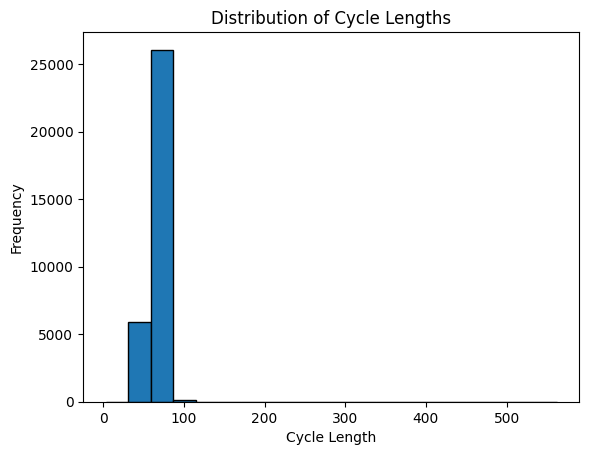

In [25]:
# plot distribution of cycle lengths
plt.hist(cycle_lengths, bins=20, edgecolor='black')
plt.xlabel('Cycle Length')
plt.ylabel('Frequency')
plt.title('Distribution of Cycle Lengths')
plt.show()


In [26]:
lower_bound, upper_bound

(51.0, 75.0)

In [27]:
def biomech_metrics(gc_len):
    gait_cycle_duration = gc_len / 60
    gait_cycles_per_min = 60 / gait_cycle_duration
    steps_per_min = 2 * gait_cycles_per_min

    print(f"Gait cycle duration: {gait_cycle_duration} seconds")
    print(f"Gait cycles per minute: {gait_cycles_per_min}")
    print(f"Steps per minute: {steps_per_min}")

    return gait_cycle_duration, gait_cycles_per_min, steps_per_min

In [28]:
lower_gc_duration, lower_gc_per_min, lower_step_per_min = biomech_metrics(lower_bound)

Gait cycle duration: 0.85 seconds
Gait cycles per minute: 70.58823529411765
Steps per minute: 141.1764705882353


In [29]:
upper_gc_duration, upper_gc_per_min, upper_step_per_min = biomech_metrics(upper_bound)

Gait cycle duration: 1.25 seconds
Gait cycles per minute: 48.0
Steps per minute: 96.0


Surface: walk, Min Length: 51, Max Length: 75, Count: 16731
Surface: stairs_down, Min Length: 51, Max Length: 75, Count: 1019
Surface: stairs_up, Min Length: 51, Max Length: 75, Count: 2053
Surface: slope_down, Min Length: 51, Max Length: 75, Count: 5608
Surface: slope_up, Min Length: 51, Max Length: 75, Count: 4043


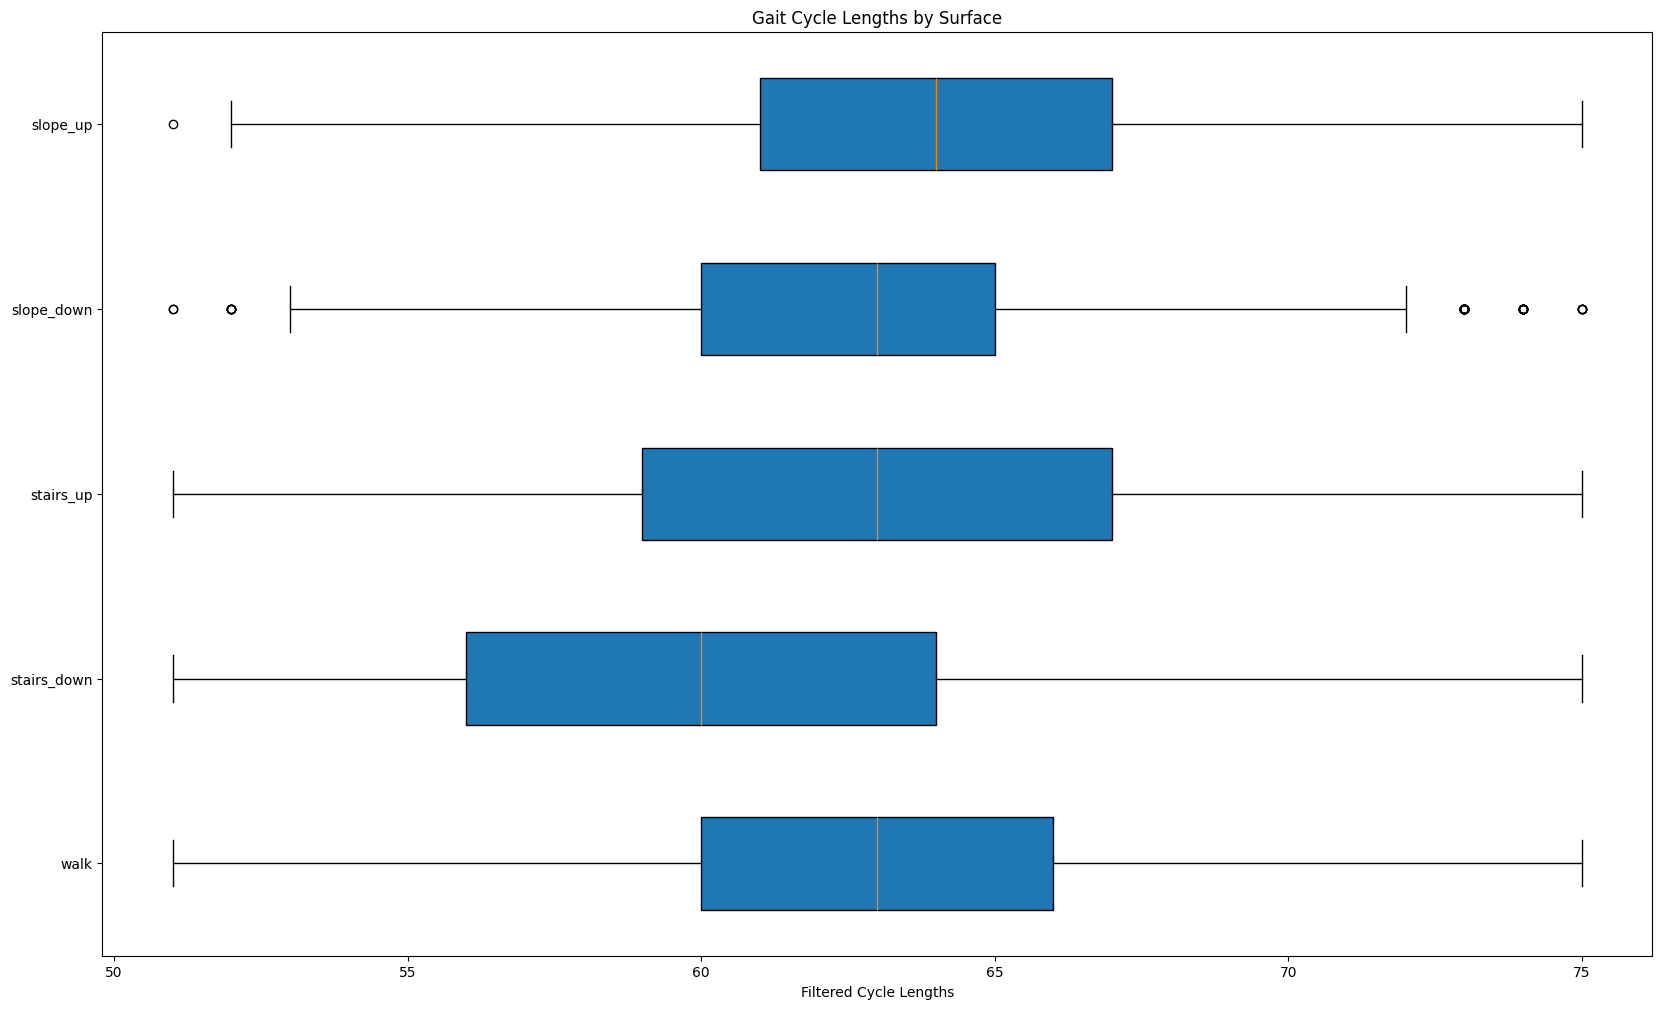

In [30]:
# Print summary of filtered cycle lengths for each surface type
for surface, lengths in filtered_cycle_lengths_by_surface.items():
    print(f"Surface: {surface}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_surface.keys()
data = filtered_cycle_lengths_by_surface.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Surface')
plt.show()

Participant: 1, Min Length: 51, Max Length: 75, Count: 1670
Participant: 2, Min Length: 51, Max Length: 73, Count: 1499
Participant: 3, Min Length: 52, Max Length: 75, Count: 1418
Participant: 4, Min Length: 51, Max Length: 73, Count: 1539
Participant: 5, Min Length: 51, Max Length: 75, Count: 1403
Participant: 7, Min Length: 51, Max Length: 75, Count: 1583
Participant: 8, Min Length: 51, Max Length: 75, Count: 1688
Participant: 10, Min Length: 51, Max Length: 75, Count: 1535
Participant: 12, Min Length: 53, Max Length: 75, Count: 1746
Participant: 13, Min Length: 51, Max Length: 75, Count: 1503
Participant: 14, Min Length: 51, Max Length: 75, Count: 1301
Participant: 15, Min Length: 52, Max Length: 75, Count: 1590
Participant: 16, Min Length: 51, Max Length: 75, Count: 1590
Participant: 17, Min Length: 52, Max Length: 75, Count: 1266
Participant: 18, Min Length: 51, Max Length: 75, Count: 1653
Participant: 19, Min Length: 51, Max Length: 70, Count: 1354
Participant: 22, Min Length: 51

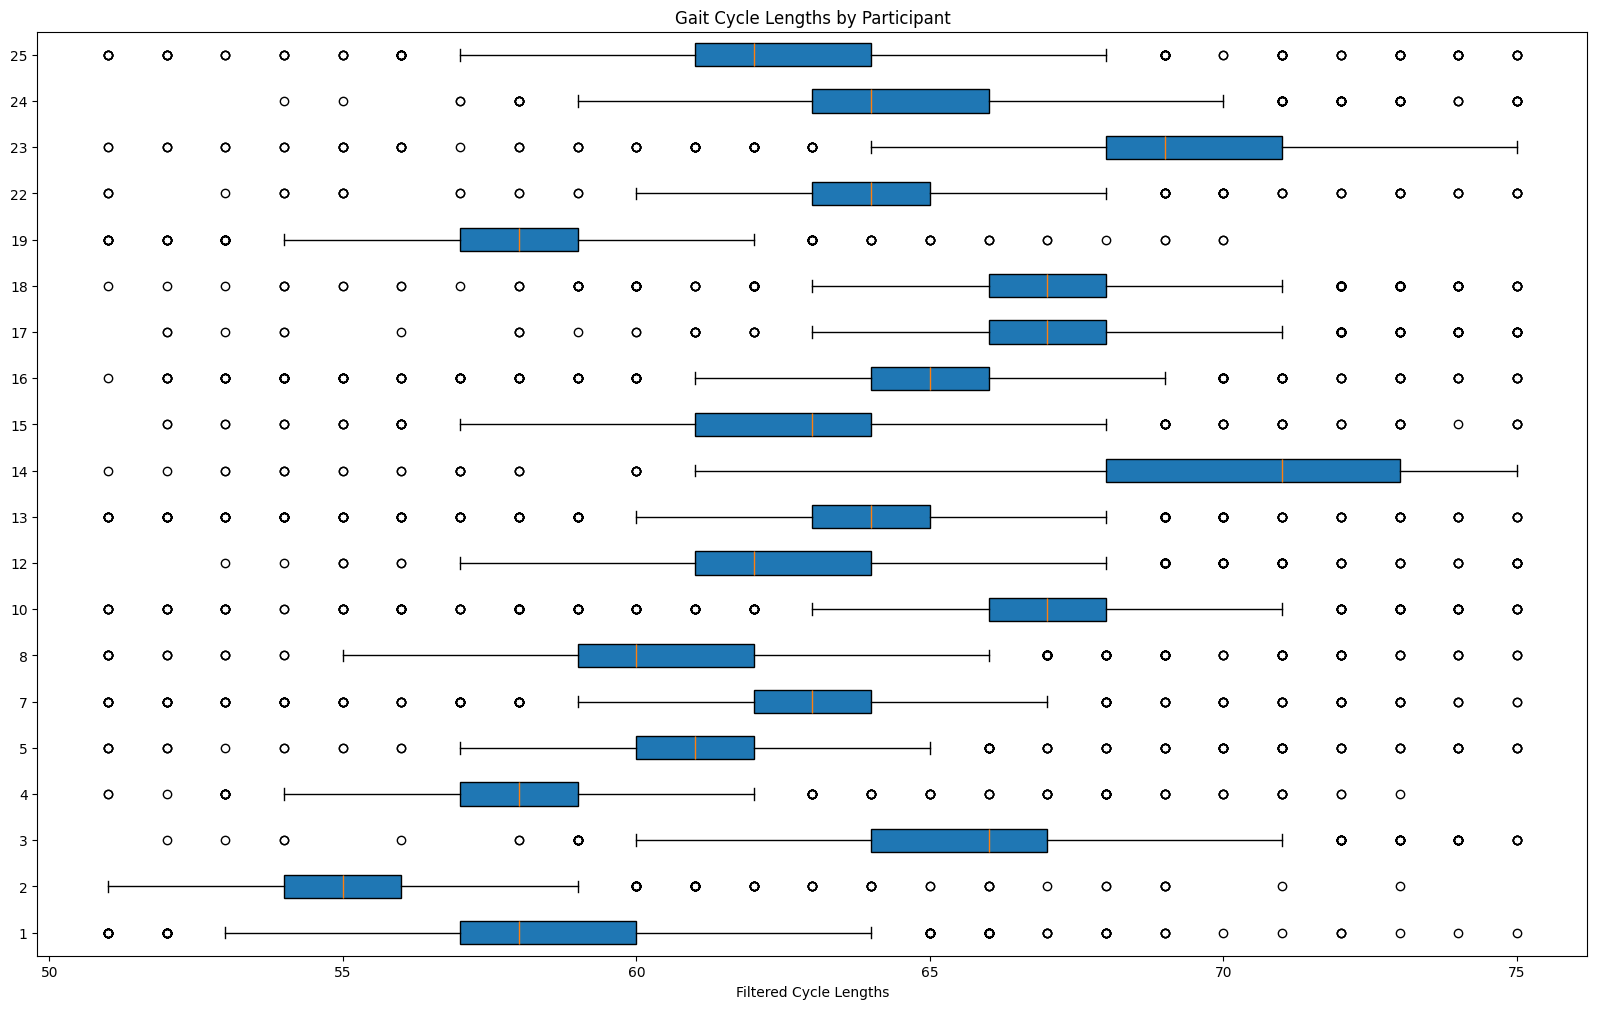

In [31]:
# Print summary of filtered cycle lengths for each surface type
for participant, lengths in filtered_cycle_lengths_by_participant.items():
    print(f"Participant: {participant}, Min Length: {min(lengths)}, Max Length: {max(lengths)}, Count: {len(lengths)}")

# Visualize the filtered cycle lengths using a box plot
labels = filtered_cycle_lengths_by_participant.keys()
data = filtered_cycle_lengths_by_participant.values()

plt.figure(figsize=(20, 12))
plt.boxplot(data, vert=False, patch_artist=True, labels=labels)

# Add labels and title to the plot
plt.xlabel('Filtered Cycle Lengths')
plt.title('Gait Cycle Lengths by Participant')
plt.show()

## Wide variety participants

In [32]:
# # participant 15
# ppant_15 = insole_df[insole_df['participant_id'] == 15]
# ppant_15.sort_values(by=['task', 'time', 'sensor_location'], inplace=True)

# ppant_15_A = ppant_15[ppant_15['task'] == 'A']
# ppant_15_B = ppant_15[ppant_15['task'] == 'B']
# ppant_15_C = ppant_15[ppant_15['task'] == 'C']

# ppant_15_A_right_cumulative =  ppant_15_A['Right_norm_cumulative'].values
# ppant_15_A_left_cumulative =  ppant_15_A['Left_norm_cumulative'].values

# import matplotlib.pyplot as plt

# # Set up the figure with two subplots
# fig, axs = plt.subplots(2, 1, figsize=(200, 12), sharex=True)

# # Right Cumulative Steps Plot
# axs[0].plot(ppant_15_A['time'], ppant_15_A_right_cumulative, color='blue')
# axs[0].set_title("Right Cumulative Steps", fontsize=16)
# axs[0].set_ylabel("Cumulative Steps (Right)", fontsize=14)
# axs[0].grid(True, linestyle='--', linewidth=0.5)

# # Left Cumulative Steps Plot
# axs[1].plot(ppant_15_A['time'], ppant_15_A_left_cumulative, color='green')
# axs[1].set_title("Left Cumulative Steps", fontsize=16)
# axs[1].set_ylabel("Cumulative Steps (Left)", fontsize=14)
# axs[1].set_xlabel("Time", fontsize=14)
# axs[1].grid(True, linestyle='--', linewidth=0.5)

# # Adjust layout
# plt.tight_layout()

# # Show the plots
# plt.show()

In [33]:
# # participant 14

# ppant_14 = insole_df[insole_df['participant_id'] == 14]
# ppant_14.sort_values(by=['task', 'time', 'sensor_location'], inplace=True)

# ppant_14_A = ppant_14[ppant_14['task'] == 'A']
# ppant_14_B = ppant_14[ppant_14['task'] == 'B']
# ppant_14_C = ppant_14[ppant_14['task'] == 'C']

# ppant_14_A_right_cumulative =  ppant_14_A['Right_norm_cumulative'].values
# ppant_14_A_left_cumulative =  ppant_14_A['Left_norm_cumulative'].values

# import matplotlib.pyplot as plt

# # Set up the figure with two subplots
# fig, axs = plt.subplots(2, 1, figsize=(200, 12), sharex=True)

# # Right Cumulative Steps Plot
# axs[0].plot(ppant_14_A['time'], ppant_14_A_right_cumulative, color='blue')
# axs[0].set_title("Right Cumulative Steps", fontsize=16)
# axs[0].set_ylabel("Cumulative Steps (Right)", fontsize=14)
# axs[0].grid(True, linestyle='--', linewidth=0.5)

# # Left Cumulative Steps Plot
# axs[1].plot(ppant_14_A['time'], ppant_14_A_left_cumulative, color='green')
# axs[1].set_title("Left Cumulative Steps", fontsize=16)
# axs[1].set_ylabel("Cumulative Steps (Left)", fontsize=14)
# axs[1].set_xlabel("Time", fontsize=14)
# axs[1].grid(True, linestyle='--', linewidth=0.5)

# # Adjust layout
# plt.tight_layout()

# # Show the plots
# plt.show()

In [34]:
# # participant 5

# ppant_5 = insole_df[insole_df['participant_id'] == 5]
# ppant_5.sort_values(by=['task', 'time', 'sensor_location'], inplace=True)

# ppant_5_A = ppant_5[ppant_5['task'] == 'A']
# ppant_5_B = ppant_5[ppant_5['task'] == 'B']
# ppant_5_C = ppant_5[ppant_5['task'] == 'C']

# ppant_5_A_right_cumulative =  ppant_5_A['Right_norm_cumulative'].values
# ppant_5_A_left_cumulative =  ppant_5_A['Left_norm_cumulative'].values

# import matplotlib.pyplot as plt

# # Set up the figure with two subplots
# fig, axs = plt.subplots(2, 1, figsize=(200, 12), sharex=True)

# # Right Cumulative Steps Plot
# axs[0].plot(ppant_5_A['time'], ppant_5_A_right_cumulative, color='blue')
# axs[0].set_title("Right Cumulative Steps", fontsize=16)
# axs[0].set_ylabel("Cumulative Steps (Right)", fontsize=14)
# axs[0].grid(True, linestyle='--', linewidth=0.5)

# # Left Cumulative Steps Plot
# axs[1].plot(ppant_5_A['time'], ppant_5_A_left_cumulative, color='green')
# axs[1].set_title("Left Cumulative Steps", fontsize=16)
# axs[1].set_ylabel("Cumulative Steps (Left)", fontsize=14)
# axs[1].set_xlabel("Time", fontsize=14)
# axs[1].grid(True, linestyle='--', linewidth=0.5)

# # Adjust layout
# plt.tight_layout()

# # Show the plots
# plt.show()

## "Normal" Participants to Compare

In [35]:
# # participant 12 for comparison

# ppant_12 = insole_df[insole_df['participant_id'] == 12]
# ppant_12.sort_values(by=['task', 'time', 'sensor_location'], inplace=True)

# ppant_12_A = ppant_12[ppant_12['task'] == 'A']
# ppant_12_B = ppant_12[ppant_12['task'] == 'B']
# ppant_12_C = ppant_12[ppant_12['task'] == 'C']

# ppant_12_A_right_cumulative =  ppant_12_A['Right_norm_cumulative'].values
# ppant_12_A_left_cumulative =  ppant_12_A['Left_norm_cumulative'].values

# import matplotlib.pyplot as plt

# # Set up the figure with two subplots
# fig, axs = plt.subplots(2, 1, figsize=(200, 12), sharex=True)

# # Right Cumulative Steps Plot
# axs[0].plot(ppant_12_A['time'], ppant_12_A_right_cumulative, color='blue')
# axs[0].set_title("Right Cumulative Steps", fontsize=16)
# axs[0].set_ylabel("Cumulative Steps (Right)", fontsize=14)
# axs[0].grid(True, linestyle='--', linewidth=0.5)

# # Left Cumulative Steps Plot
# axs[1].plot(ppant_12_A['time'], ppant_12_A_left_cumulative, color='green')
# axs[1].set_title("Left Cumulative Steps", fontsize=16)
# axs[1].set_ylabel("Cumulative Steps (Left)", fontsize=14)
# axs[1].set_xlabel("Time", fontsize=14)
# axs[1].grid(True, linestyle='--', linewidth=0.5)

# # Adjust layout
# plt.tight_layout()

# # Show the plots
# plt.show()

In [36]:
# # participant 12 for comparison

# ppant_2 = insole_df[insole_df['participant_id'] == 2]
# ppant_2.sort_values(by=['task', 'time', 'sensor_location'], inplace=True)

# ppant_2_A = ppant_2[ppant_2['task'] == 'A']
# ppant_2_B = ppant_2[ppant_2['task'] == 'B']
# ppant_2_C = ppant_2[ppant_2['task'] == 'C']

# ppant_2_A_right_cumulative =  ppant_2_A['Right_norm_cumulative'].values
# ppant_2_A_left_cumulative =  ppant_2_A['Left_norm_cumulative'].values

# # Set up the figure with two subplots
# fig, axs = plt.subplots(2, 1, figsize=(200, 12), sharex=True)

# # Right Cumulative Steps Plot
# axs[0].plot(ppant_2_A['time'], ppant_2_A_right_cumulative, color='blue')
# axs[0].set_title("Right Cumulative Steps", fontsize=16)
# axs[0].set_ylabel("Cumulative Steps (Right)", fontsize=14)
# axs[0].grid(True, linestyle='--', linewidth=0.5)

# # Left Cumulative Steps Plot
# axs[1].plot(ppant_2_A['time'], ppant_2_A_left_cumulative, color='green')
# axs[1].set_title("Left Cumulative Steps", fontsize=16)
# axs[1].set_ylabel("Cumulative Steps (Left)", fontsize=14)
# axs[1].set_xlabel("Time", fontsize=14)
# axs[1].grid(True, linestyle='--', linewidth=0.5)

# # Adjust layout
# plt.tight_layout()

# # Show the plots
# plt.show()

## continued

In [37]:
filtered_final_combined_df['cycle_length'] = calculate_cycle_lengths(filtered_final_combined_df).reindex(
    filtered_final_combined_df['gait_cycle_id']).values

<ipython-input-37-f5f0f8ea82ed>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_final_combined_df['cycle_length'] = calculate_cycle_lengths(filtered_final_combined_df).reindex(


In [39]:
len(filtered_final_combined_df)

15418600

In [40]:
len(insole_df)

16209632

In [41]:
all_gait_cycles = filtered_final_combined_df.copy()

In [42]:
def interpolate_to_fixed_length(group, target_length=80):
    interpolated_group = []

    # Iterate over each sensor location within the group
    for sensor_location, data in group.groupby('sensor_location'):
        # Select only numeric columns for interpolation
        numeric_data = data[['time', 'Left_raw', 'Right_raw', 'Left_norm', 'Right_norm', 'Left_norm_cumulative', 'Right_norm_cumulative']]
        numeric_data = numeric_data.reset_index(drop=True)
        original_length = len(numeric_data)

        if original_length < 2:
            # Skip groups with insufficient data for interpolation
            print(f"Skipping sensor_location '{sensor_location}' with insufficient data.")
            continue

        # Create new evenly spaced indices
        new_indices = np.linspace(0, original_length - 1, target_length)

        # Interpolate the numeric data to the new indices
        interpolated_data = pd.DataFrame(
            {col: np.interp(new_indices, np.arange(original_length), numeric_data[col])
             for col in numeric_data.columns},
            index=new_indices
        )

        # Add back the sensor location information
        interpolated_data['sensor_location'] = sensor_location
        interpolated_data['gait_cycle_id'] = group['gait_cycle_id'].iloc[0]
        interpolated_data['walk_mode'] = group['walk_mode'].iloc[0]

        # Append to the results list
        interpolated_group.append(interpolated_data)

    # Combine all sensor locations back into a single DataFrame
    return pd.concat(interpolated_group, axis=0) if interpolated_group else pd.DataFrame()


In [43]:
# Apply the interpolation function
df_interpolated = (
    all_gait_cycles.groupby('gait_cycle_id')
    .apply(interpolate_to_fixed_length)
    .reset_index(drop=True)
)


<ipython-input-43-10383d9c33e5>:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(interpolate_to_fixed_length)


<ipython-input-44-53fdebd6322c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_df_interp.sort_values(by=['time'], inplace=True)


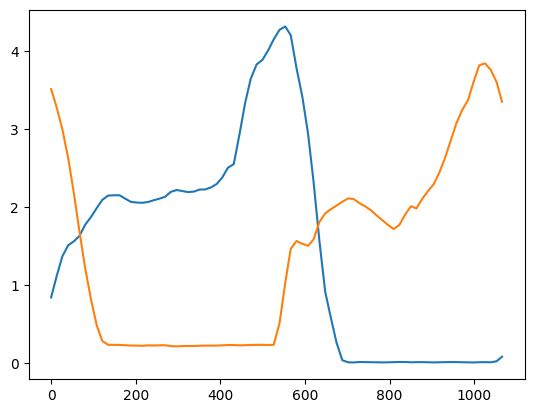

In [44]:
plot_df_interp = df_interpolated[df_interpolated['gait_cycle_id'] == '1_1.0_A']
plot_df_interp.sort_values(by=['time'], inplace=True)
plt.plot(plot_df_interp['time'], plot_df_interp['Left_norm_cumulative'])
plt.plot(plot_df_interp['time'], plot_df_interp['Right_norm_cumulative'])

In [45]:
max(plot_df_interp['time'])-min(plot_df_interp['time'])

1066.0

In [ ]:
df_interpolated.sort_values(by=['gait_cycle_id', 'time'], inplace=True)

In [46]:
df_interpolated.to_csv('/content/drive/MyDrive/Next_Step/Honda: multi_modal_gait_database/merged/interpolated_insole_sensor_df.csv', index=False)